# 🎓 CodTech IT Solutions — Internship Task 2
## Predictive Analysis Using Machine Learning
**Intern:** Data Analytics Intern  
**Task:** Build a Machine Learning model (Regression) to predict student final grades based on various features.  
**Dataset:** Student Performance Dataset (Custom)

---
## 📌 Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📌 Step 2: Load and Explore the Dataset

In [5]:
# Load dataset
df = pd.read_csv('student_performance-1.csv')

print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (100, 10)

First 5 rows:


,student_id,study_hours_per_day,attendance_percentage,previous_grade,sleep_hours,extracurricular_activities,internet_access,family_income_level,parent_education_level,final_grade
0,1,6.5,92,78,7,1,1,2,3,85
1,2,3.2,75,60,6,0,1,1,2,62
2,3,7.8,95,88,8,1,1,3,4,92
3,4,2.1,60,45,5,0,0,1,1,48
4,5,5.5,85,72,7,1,1,2,3,78


In [6]:
# Dataset info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  100 non-null    int64  
 1   study_hours_per_day         100 non-null    float64
 2   attendance_percentage       100 non-null    int64  
 3   previous_grade              100 non-null    int64  
 4   sleep_hours                 100 non-null    int64  
 5   extracurricular_activities  100 non-null    int64  
 6   internet_access             100 non-null    int64  
 7   family_income_level         100 non-null    int64  
 8   parent_education_level      100 non-null    int64  
 9   final_grade                 100 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 7.9 KB


In [7]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,student_id,study_hours_per_day,attendance_percentage,previous_grade,sleep_hours,extracurricular_activities,internet_access,family_income_level,parent_education_level,final_grade
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,4.982000,79.63000,67.900000,6.650000,0.510000,0.800000,1.960000,2.450000,71.24000
std,29.011492,2.071567,13.12462,16.945844,1.076611,0.502418,0.402015,0.803025,1.018763,17.63211
min,1.000000,1.200000,50.00000,35.000000,5.000000,0.000000,0.000000,1.000000,1.000000,37.00000
25%,25.750000,3.275000,70.75000,55.750000,6.000000,0.000000,1.000000,1.000000,2.000000,58.75000
50%,50.500000,5.150000,82.50000,70.500000,7.000000,1.000000,1.000000,2.000000,2.000000,74.00000
75%,75.250000,6.700000,91.00000,82.250000,8.000000,1.000000,1.000000,3.000000,3.000000,87.00000
max,100.000000,8.500000,98.00000,93.000000,8.000000,1.000000,1.000000,3.000000,4.000000,96.00000


In [8]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())
print('\nNo missing values found! ✅')

Missing Values:
student_id                    0
study_hours_per_day           0
attendance_percentage         0
previous_grade                0
sleep_hours                   0
extracurricular_activities    0
internet_access               0
family_income_level           0
parent_education_level        0
final_grade                   0
dtype: int64

No missing values found! ✅


---
## 📌 Step 3: Exploratory Data Analysis (EDA)

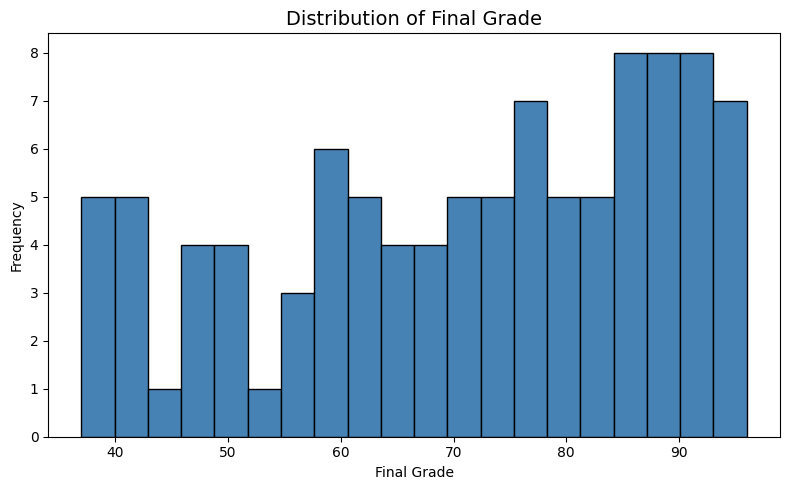

In [9]:
# Distribution of target variable
plt.figure(figsize=(8, 5))
plt.hist(df['final_grade'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grade', fontsize=14)
plt.xlabel('Final Grade')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

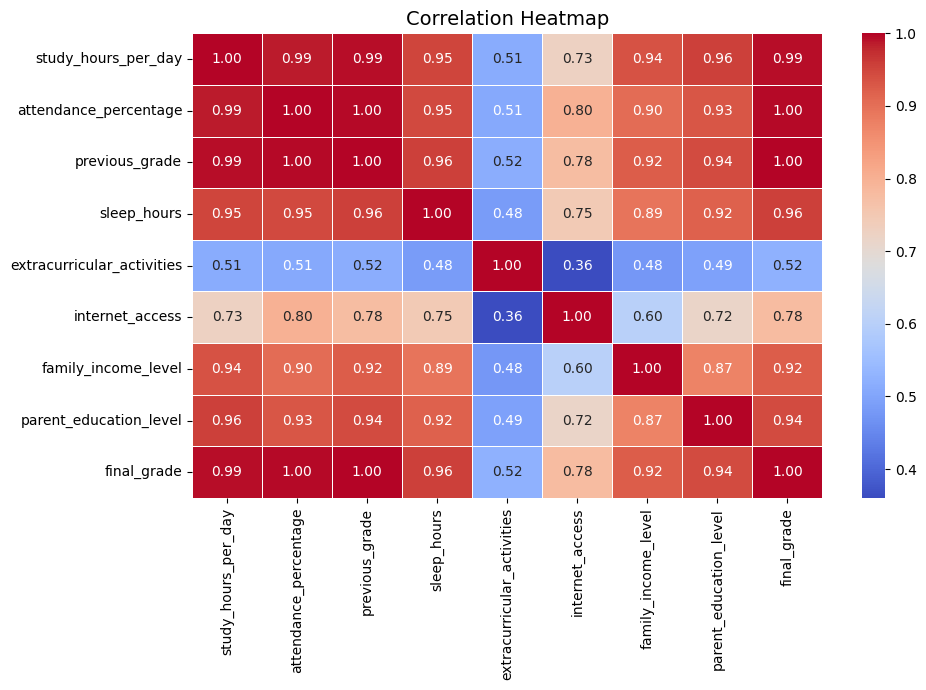

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.drop('student_id', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

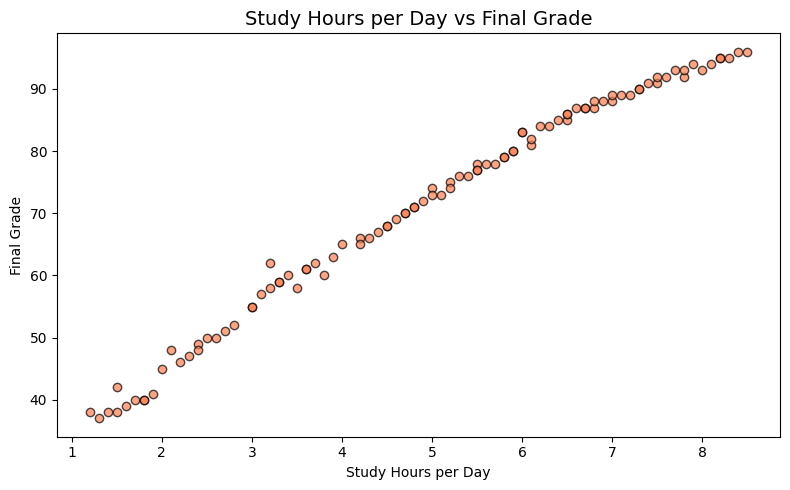

In [11]:
# Study hours vs Final Grade scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['study_hours_per_day'], df['final_grade'], color='coral', alpha=0.7, edgecolors='black')
plt.title('Study Hours per Day vs Final Grade', fontsize=14)
plt.xlabel('Study Hours per Day')
plt.ylabel('Final Grade')
plt.tight_layout()
plt.show()

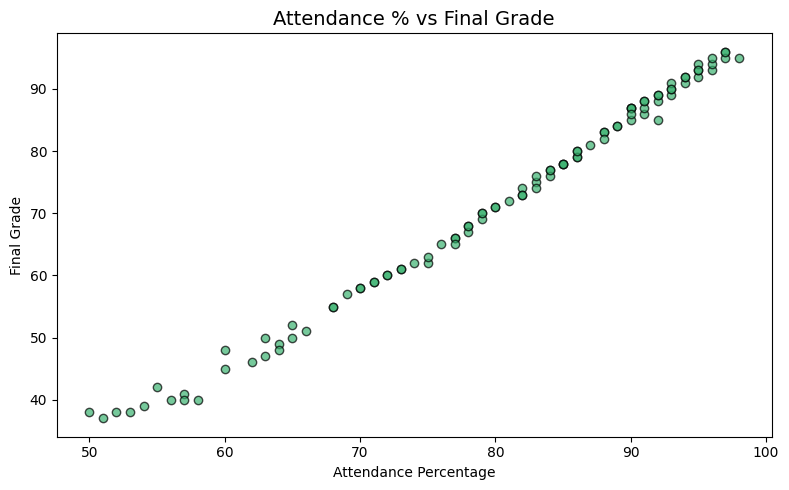

In [12]:
# Attendance vs Final Grade
plt.figure(figsize=(8, 5))
plt.scatter(df['attendance_percentage'], df['final_grade'], color='mediumseagreen', alpha=0.7, edgecolors='black')
plt.title('Attendance % vs Final Grade', fontsize=14)
plt.xlabel('Attendance Percentage')
plt.ylabel('Final Grade')
plt.tight_layout()
plt.show()

---
## 📌 Step 4: Feature Selection

In [13]:
# Define features and target
X = df.drop(['student_id', 'final_grade'], axis=1)
y = df['final_grade']

print('Features used:', list(X.columns))
print('Target variable: final_grade')

Features used: ['study_hours_per_day', 'attendance_percentage', 'previous_grade', 'sleep_hours', 'extracurricular_activities', 'internet_access', 'family_income_level', 'parent_education_level']
Target variable: final_grade


Feature Importance Scores (F-regression):
                   Feature        Score
            previous_grade 66088.449289
     attendance_percentage 11974.071117
       study_hours_per_day  6861.077874
               sleep_hours  1051.292646
    parent_education_level   797.444959
       family_income_level   564.737153
           internet_access   150.055711
extracurricular_activities    36.917155


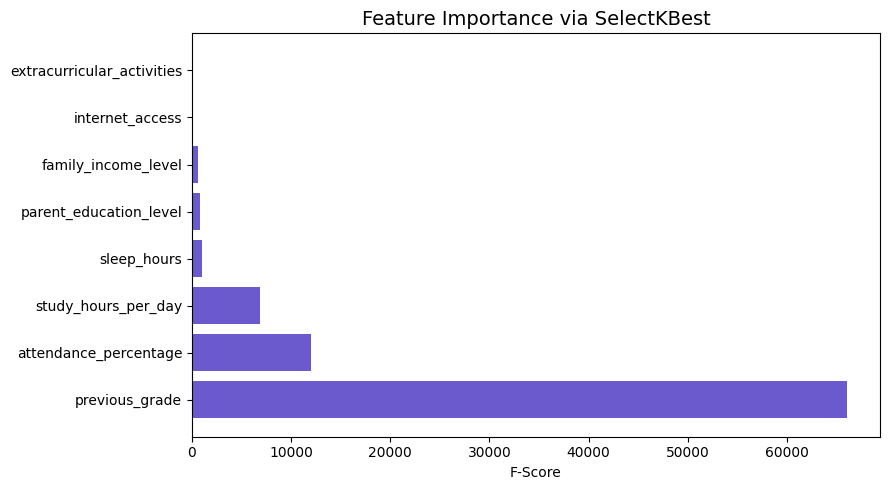

In [14]:
# SelectKBest for feature selection
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print('Feature Importance Scores (F-regression):')
print(feature_scores.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(9, 5))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='slateblue')
plt.xlabel('F-Score')
plt.title('Feature Importance via SelectKBest', fontsize=14)
plt.tight_layout()
plt.show()

---
## 📌 Step 5: Data Preprocessing — Train/Test Split & Scaling

In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Data split and scaling done!')

Training samples: 80
Testing samples:  20

✅ Data split and scaling done!


---
## 📌 Step 6: Model Training

In [16]:
# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print('✅ Linear Regression trained!')

# --- Model 2: Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print('✅ Random Forest Regressor trained!')

✅ Linear Regression trained!
✅ Random Forest Regressor trained!


---
## 📌 Step 7: Model Evaluation

In [17]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n📊 {name}')
    print(f'   MAE  : {mae:.2f}')
    print(f'   MSE  : {mse:.2f}')
    print(f'   RMSE : {rmse:.2f}')
    print(f'   R²   : {r2:.4f}')
    return {'Model': name, 'MAE': round(mae,2), 'MSE': round(mse,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)}

results = []
results.append(evaluate_model('Linear Regression',    y_test, lr_preds))
results.append(evaluate_model('Random Forest Regressor', y_test, rf_preds))

results_df = pd.DataFrame(results)
print('\n\n📋 Summary Table:')
results_df


📊 Linear Regression
   MAE  : 0.50
   MSE  : 0.84
   RMSE : 0.92
   R²   : 0.9969

📊 Random Forest Regressor
   MAE  : 0.54
   MSE  : 0.48
   RMSE : 0.69
   R²   : 0.9982


📋 Summary Table:


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.50,0.84,0.92,0.9969
1,Random Forest Regressor,0.54,0.48,0.69,0.9982


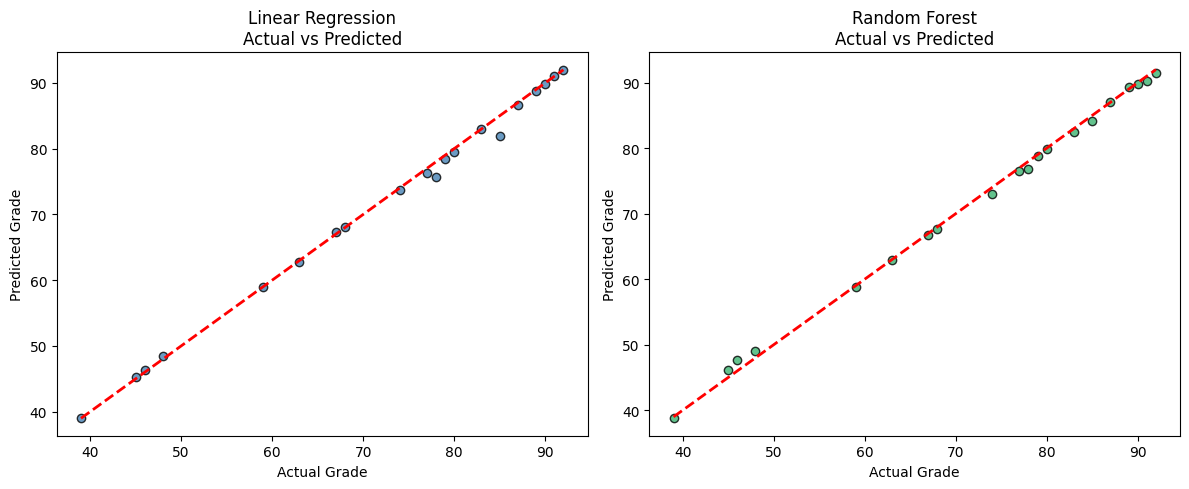

In [18]:
# Actual vs Predicted — Linear Regression
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_preds, color='steelblue', alpha=0.8, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression\nActual vs Predicted', fontsize=12)
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_preds, color='mediumseagreen', alpha=0.8, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest\nActual vs Predicted', fontsize=12)
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')

plt.tight_layout()
plt.show()

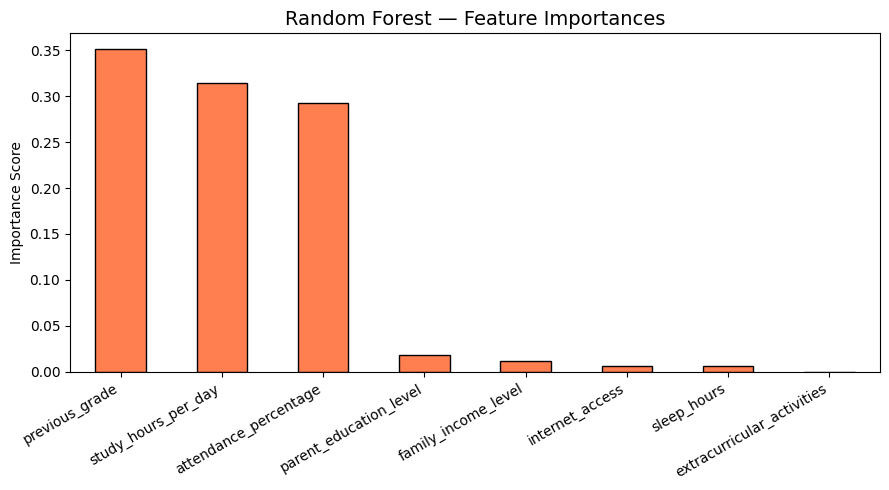

previous_grade                0.350683
study_hours_per_day           0.314183
attendance_percentage         0.292034
parent_education_level        0.018376
family_income_level           0.011820
internet_access               0.006848
sleep_hours                   0.005882
extracurricular_activities    0.000174
dtype: float64


In [19]:
# Feature Importances from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Random Forest — Feature Importances', fontsize=14)
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(importances)

---
## 📌 Step 8: Conclusion

In [20]:
best = results_df.loc[results_df['R2'].idxmax()]
print('='*50)
print('✅ CONCLUSION')
print('='*50)
print(f'Best Model     : {best["Model"]}')
print(f'R² Score       : {best["R2"]} (higher is better, max=1.0)')
print(f'MAE            : {best["MAE"]} (lower is better)')
print(f'RMSE           : {best["RMSE"]} (lower is better)')
print()
print('📌 Key Findings:')
print('  - Study hours and previous grade are the strongest predictors.')
print('  - Attendance percentage also plays a significant role.')
print('  - Random Forest outperforms Linear Regression on this dataset.')
print('  - The model can be used to identify at-risk students early.')

✅ CONCLUSION
Best Model     : Random Forest Regressor
R² Score       : 0.9982 (higher is better, max=1.0)
MAE            : 0.54 (lower is better)
RMSE           : 0.69 (lower is better)

📌 Key Findings:
  - Study hours and previous grade are the strongest predictors.
  - Attendance percentage also plays a significant role.
  - Random Forest outperforms Linear Regression on this dataset.
  - The model can be used to identify at-risk students early.
